In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# 1. Load Data Berlabel
try:
    df = pd.read_csv('dataset_labeled.csv')
    print("Data berhasil dimuat.")
except FileNotFoundError:
    print("Error: File 'dataset_labeled.csv' tidak ditemukan. Jalankan Tahap 3 dulu.")

# 2. Cek Data Kosong (Penting!)
# Kadang proses cleaning menyisakan baris kosong (NaN), harus dibuang
# Fix: Changed 'text_clean' to 'text' as per the available DataFrame columns
df = df.dropna(subset=['text_stemmed', 'label_otomatis'])

# 3. Definisikan X (Teks) dan y (Label)
# Fix: Changed 'text_clean' to 'text'
X_raw = df['text_stemmed']
y_raw = df['label_otomatis']

print(f"Jumlah Data Siap Proses: {len(df)}")
print(f"Contoh Label Asli: {y_raw.unique()}")

Data berhasil dimuat.
Jumlah Data Siap Proses: 1069
Contoh Label Asli: ['Negatif' 'Netral' 'Positif']


In [ ]:
# Inisialisasi Encoder
le = LabelEncoder()

# Ubah label teks ke angka
y = le.fit_transform(y_raw)

# Cek hasil encoding
print("Label Encoding Mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label} = {i}")

# Sekarang 'y' berisi angka, bukan lagi teks "Positif/Negatif"
print("\nContoh 5 label pertama (angka):", y[:5])

Label Encoding Mapping:
Negatif = 0
Netral = 1
Positif = 2

Contoh 5 label pertama (angka): [0 1 0 2 0]


In [ ]:
# Inisialisasi TF-IDF
# max_features=1000 artinya kita hanya mengambil 1000 kata terpenting/tersering
# tujuannya agar komputasi tidak terlalu berat dan menghilangkan noise
tfidf = TfidfVectorizer(max_features=1000)

# Fit & Transform (Pelajari kosakata & ubah jadi angka)
X = tfidf.fit_transform(X_raw)

print("Proses TF-IDF Selesai!")
print(f"Ukuran Matriks Data (Baris, Kolom/Fitur): {X.shape}")
# Baris = Jumlah komentar
# Kolom = Jumlah kosakata unik yang diambil (max 1000)

Proses TF-IDF Selesai!
Ukuran Matriks Data (Baris, Kolom/Fitur): (1069, 1000)


In [ ]:
# Kita ambil contoh 5 kalimat pertama saja untuk ditampilkan
df_tfidf = pd.DataFrame(
    X[:5].toarray(),
    columns=tfidf.get_feature_names_out()
)

print("--- Tabel Bobot Kata (TF-IDF) ---")
# Menampilkan kata-kata yang memiliki nilai (bukan 0) pada kalimat pertama
sample_row = df_tfidf.iloc[0]
print(sample_row[sample_row > 0])

# Menampilkan dataframe
df_tfidf.head()

--- Tabel Bobot Kata (TF-IDF) ---
google    0.456643
lama      0.353702
pakai     0.262390
pixel     0.432508
raw       0.432508
sejak     0.472650
Name: 0, dtype: float64


,abang,ada,adapter,adaptor,ah,ahli,ai,aing,air,airpods,...,wow,xiaomi,xiomi,xr,xs,ya,yakin,you,youtuber,zampe
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.286586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import pickle

# Simpan vectorizer
with open('tfidf_model.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model TF-IDF berhasil disimpan sebagai 'tfidf_model.pkl'")

Model TF-IDF berhasil disimpan sebagai 'tfidf_model.pkl'


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Bagi Data (80% Train, 20% Test)
# random_state=42 agar hasil pembagiannya konsisten (tidak berubah tiap di-run)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total Data: {X.shape[0]}")
print(f"Data Latih (80%): {X_train.shape[0]}")
print(f"Data Uji (20%): {X_test.shape[0]}")

Total Data: 1069
Data Latih (80%): 855
Data Uji (20%): 214


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- INISIALISASI MODEL ---
# 1. Naive Bayes (Sangat bagus untuk teks)
nb_model = MultinomialNB()

# 2. Random Forest (Bagus untuk data kompleks, n_estimators=jumlah pohon)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. K-Nearest Neighbors (KNN, n_neighbors=jumlah tetangga terdekat)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Masukkan ke dictionary agar mudah di-loop
models = {
    "Naive Bayes": nb_model,
    "Random Forest": rf_model,
    "KNN": knn_model
}

# --- LOOPING TRAINING & EVALUASI ---
results = {}

print("--- HASIL EVALUASI MODEL ---\n")

for name, model in models.items():
    print(f"Training model: {name}...")

    # 1. Latih Model (Fit)
    model.fit(X_train, y_train)

    # 2. Prediksi ke Data Uji
    y_pred = model.predict(X_test)

    # 3. Hitung Akurasi
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    # 4. Tampilkan Report Lengkap
    print(f"\n>> ALGORITMA: {name}")
    print(f"Akurasi: {acc*100:.2f}%")
    print("Classification Report:")
    # target_names menyesuaikan urutan label encoder (0, 1, 2)
    # Biasanya: 0=Negatif, 1=Netral, 2=Positif (Cek print le.classes_ di Tahap 4)
    print(classification_report(y_test, y_pred))
    print("-" * 60)

--- HASIL EVALUASI MODEL ---

Training model: Naive Bayes...

>> ALGORITMA: Naive Bayes
Akurasi: 61.21%
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.58      0.65        90
           1       0.75      0.08      0.15        36
           2       0.55      0.86      0.67        88

    accuracy                           0.61       214
   macro avg       0.68      0.51      0.49       214
weighted avg       0.66      0.61      0.57       214

------------------------------------------------------------
Training model: Random Forest...

>> ALGORITMA: Random Forest
Akurasi: 69.16%
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.68      0.73        90
           1       0.52      0.61      0.56        36
           2       0.68      0.74      0.71        88

    accuracy                           0.69       214
   macro avg       0.67      0.68      0.67       214
weig

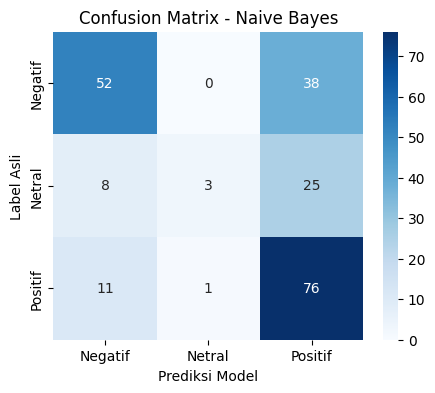

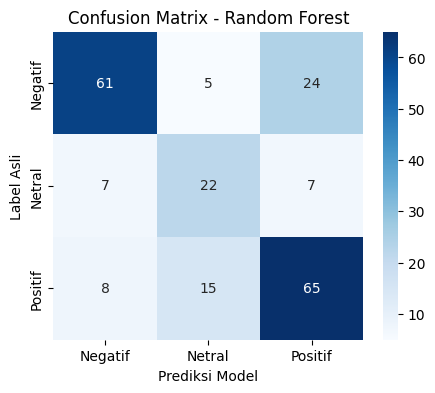

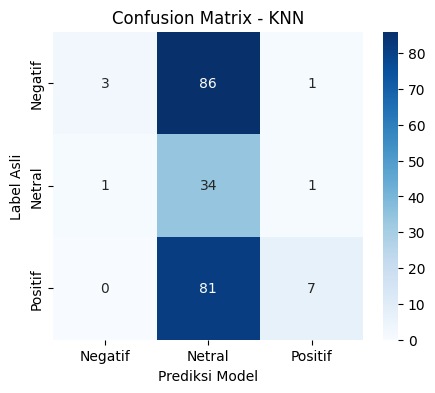

In [ ]:
# Kita buat fungsi visualisasi agar rapi
def plot_confusion_matrix(model, name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Label Asli')
    plt.xlabel('Prediksi Model')
    plt.show()

# Tampilkan Matrix untuk ketiga model
for name, model in models.items():
    plot_confusion_matrix(model, name)

/tmp/ipython-input-937481810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algoritma', y='Akurasi', data=df_results, palette='viridis')


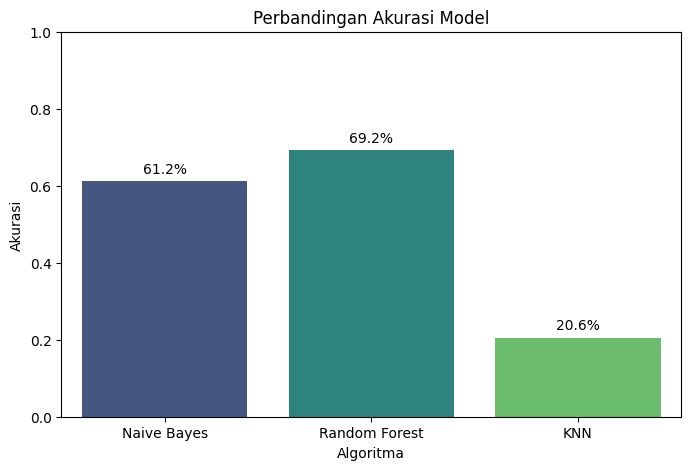

In [ ]:
# Buat DataFrame dari hasil akurasi
df_results = pd.DataFrame(list(results.items()), columns=['Algoritma', 'Akurasi'])

# Plot Grafik
plt.figure(figsize=(8, 5))
sns.barplot(x='Algoritma', y='Akurasi', data=df_results, palette='viridis')
plt.ylim(0, 1.0) # Set batas Y dari 0 sampai 1
plt.title('Perbandingan Akurasi Model')
plt.ylabel('Akurasi')
plt.xlabel('Algoritma')

# Tambahkan label angka di atas batang
for index, row in df_results.iterrows():
    plt.text(index, row.Akurasi + 0.02, f"{row.Akurasi*100:.1f}%",
             color='black', ha="center")

plt.show()

In [ ]:
import re # Import regex for cleaning

def proses_pembersihan(text):
    # 1. Mengubah ke lowercase
    text = text.lower()
    # 2. Menghapus karakter non-alphanumeric (kecuali spasi)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # 3. Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def prediksi_komentar(kalimat):
    # 1. Preprocessing (Gunakan fungsi cleaning dari Tahap 2)
    # Asumsi fungsi 'proses_pembersihan' dari tahap 2 masih ada
    clean = proses_pembersihan(kalimat)

    # 2. Vektorisasi (Gunakan TF-IDF yang sudah dilatih)
    vec = tfidf.transform([clean])

    # 3. Prediksi (Misal kita pakai model Naive Bayes sebagai juara)
    pred_index = nb_model.predict(vec)[0]
    pred_label = le.inverse_transform([pred_index])[0]

    return pred_label

# Contoh penggunaan
print("--- TES PREDIKSI MANUAL ---")
contoh1 = "iPhone 17 harganya kemahalan, gak worth it banget!"
contoh2 = "Desain kameranya keren parah, inovasi terbaik Apple."

print(f"Kalimat: '{contoh1}' -> Sentimen: {prediksi_komentar(contoh1)}")
print(f"Kalimat: '{contoh2}' -> Sentimen: {prediksi_komentar(contoh2)}")

--- TES PREDIKSI MANUAL ---
Kalimat: 'iPhone 17 harganya kemahalan, gak worth it banget!' -> Sentimen: Positif
Kalimat: 'Desain kameranya keren parah, inovasi terbaik Apple.' -> Sentimen: Positif


In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Siapkan list untuk menampung hasil
comparison_data = []

print("Sedang menghitung detail metrik...")

for name, model in models.items():
    # Prediksi
    y_pred = model.predict(X_test)

    # Hitung metrics (weighted rata-rata memperhitungkan jumlah data per kelas)
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    comparison_data.append({
        "Algoritma": name,
        "Akurasi": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Buat DataFrame
df_comparison = pd.DataFrame(comparison_data)

# Tampilkan Tabel (Copy tabel ini ke Jurnal Anda)
print("\n--- TABEL PERBANDINGAN PERFORMA ---")
print(df_comparison.round(4)) # Bulatkan 4 angka belakang koma

Sedang menghitung detail metrik...

--- TABEL PERBANDINGAN PERFORMA ---
       Algoritma  Akurasi  Precision  Recall  F1-Score
0    Naive Bayes   0.6449     0.5654  0.6449    0.5158
1  Random Forest   0.6636     0.6514  0.6636    0.6324
2            KNN   0.2570     0.5811  0.2570    0.1635


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- MENJALANKAN 10-FOLD CROSS VALIDATION ---
(Proses ini mungkin memakan waktu 1-2 menit)

Naive Bayes: Rata-rata Akurasi = 61.55% (+/- 5.46%)
Random Forest: Rata-rata Akurasi = 65.68% (+/- 4.80%)
KNN: Rata-rata Akurasi = 25.91% (+/- 3.46%)


/tmp/ipython-input-2375711047.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algoritma', y='Mean Accuracy', data=df_cv, palette='magma')


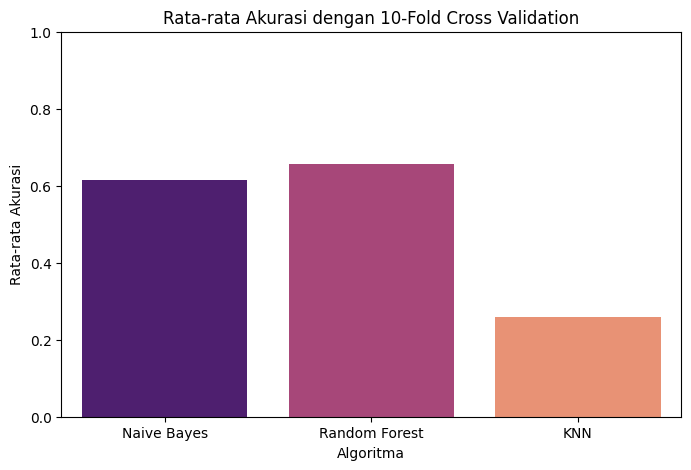

In [ ]:
from sklearn.model_selection import cross_val_score

print("--- MENJALANKAN 10-FOLD CROSS VALIDATION ---")
print("(Proses ini mungkin memakan waktu 1-2 menit)\n")

cv_results = []

for name, model in models.items():
    # Lakukan 10 kali pengujian (cv=10)
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')

    print(f"{name}: Rata-rata Akurasi = {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")

    cv_results.append({
        "Algoritma": name,
        "Mean Accuracy": scores.mean(),
        "Std Dev": scores.std()
    })

# Visualisasi Cross Validation
df_cv = pd.DataFrame(cv_results)
plt.figure(figsize=(8,5))
sns.barplot(x='Algoritma', y='Mean Accuracy', data=df_cv, palette='magma')
plt.ylim(0, 1.0)
plt.title('Rata-rata Akurasi dengan 10-Fold Cross Validation')
plt.ylabel('Rata-rata Akurasi')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate

# --- KONFIGURASI METRIK ---
# Kita ingin menghitung 4 hal sekaligus.
# 'weighted' digunakan agar perhitungan adil untuk data multi-kelas (Positif, Negatif, Netral)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

def buat_tabel_validasi(model, nama_algoritma):
    print(f"\n--- Memproses 10-Fold CV untuk: {nama_algoritma} ---")

    # Jalankan Cross Validate (ini yang menghitung Fold 1-10)
    scores = cross_validate(model, X, y, cv=10, scoring=scoring_metrics)

    # Siapkan data untuk DataFrame
    data_tabel = []

    # Loop untuk mengambil nilai per Fold (1 sampai 10)
    for i in range(10):
        data_tabel.append({
            'Fold': i + 1,
            'Accuracy (%)': scores['test_accuracy'][i] * 100,
            'Precision (%)': scores['test_precision'][i] * 100,
            'Recall (%)': scores['test_recall'][i] * 100,
            'F1 Score (%)': scores['test_f1'][i] * 100
        })

    # Buat DataFrame
    df = pd.DataFrame(data_tabel)

    # Hitung Rata-rata (Average) per kolom
    rata_rata = df.mean()
    rata_rata['Fold'] = 'Average' # Ganti angka rata-rata Fold jadi tulisan "Average"

    # Gabungkan baris rata-rata ke bawah tabel
    df_final = pd.concat([df, pd.DataFrame([rata_rata])], ignore_index=True)

    # Formatting agar rapi (Bulatkan 2 angka desimal)
    cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)']
    df_final[cols] = df_final[cols].round(2)

    # Set 'Fold' sebagai index agar terlihat seperti tabel di gambar
    df_final.set_index('Fold', inplace=True)

    return df_final

# --- EKSEKUSI UNTUK SEMUA MODEL ---
# Loop untuk Naive Bayes, Random Forest, dan KNN
dfs = {} # Simpan tabel di sini

for name, model in models.items():
    # Panggil fungsi di atas
    tabel_hasil = buat_tabel_validasi(model, name)

    # Simpan ke dictionary
    dfs[name] = tabel_hasil

    # Tampilkan Tabel
    print(f"\nTable: Validation Results of the {name} Algorithm")
    display(tabel_hasil) # 'display' khusus Colab agar tabelnya cantik
    print("="*60)

# --- OPSIONAL: SIMPAN KE EXCEL ---
# Jika ingin download untuk ditaruh di Word/Jurnal
with pd.ExcelWriter('Tabel_Validasi_Lengkap.xlsx') as writer:
    for name, df in dfs.items():
        df.to_excel(writer, sheet_name=name)

print("\nFile Excel 'Tabel_Validasi_Lengkap.xlsx' berhasil dibuat.")
print("Anda bisa download file tersebut di menu Files sebelah kiri.")


--- Memproses 10-Fold CV untuk: Naive Bayes ---

Table: Validation Results of the Naive Bayes Algorithm


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipython-input-4283934107.py:39: FutureWarnin

,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
Fold,,,,
1,59.81,65.68,59.81,56.99
2,59.81,66.87,59.81,56.22
3,68.22,69.55,68.22,64.81
4,68.22,66.22,68.22,65.60
5,57.01,48.18,57.01,51.27
6,68.22,57.02,68.22,61.67
7,54.21,44.86,54.21,48.70
8,53.27,43.71,53.27,47.67
9,65.42,54.21,65.42,59.29



--- Memproses 10-Fold CV untuk: Random Forest ---

Table: Validation Results of the Random Forest Algorithm


/tmp/ipython-input-4283934107.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Average' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rata_rata['Fold'] = 'Average' # Ganti angka rata-rata Fold jadi tulisan "Average"


,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
Fold,,,,
1,71.96,74.96,71.96,72.47
2,61.68,65.09,61.68,62.30
3,67.29,68.71,67.29,67.66
4,65.42,69.16,65.42,66.54
5,64.49,64.46,64.49,64.13
6,68.22,68.10,68.22,67.45
7,66.36,67.32,66.36,66.22
8,55.14,54.51,55.14,54.71
9,63.55,62.39,63.55,62.67



--- Memproses 10-Fold CV untuk: KNN ---

Table: Validation Results of the KNN Algorithm


/tmp/ipython-input-4283934107.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Average' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rata_rata['Fold'] = 'Average' # Ganti angka rata-rata Fold jadi tulisan "Average"


,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
Fold,,,,
1,22.43,58.56,22.43,16.89
2,24.30,59.01,24.30,19.91
3,25.23,70.01,25.23,21.63
4,34.58,80.23,34.58,34.23
5,23.36,68.76,23.36,18.56
6,27.10,61.45,27.10,22.83
7,24.30,67.49,24.30,20.01
8,22.43,65.67,22.43,14.53
9,28.04,61.87,28.04,24.91



File Excel 'Tabel_Validasi_Lengkap.xlsx' berhasil dibuat.
Anda bisa download file tersebut di menu Files sebelah kiri.


In [ ]:
# Filter data yang labelnya Positif
df_pos = df[df['label_otomatis'] == 'Positif']

# Cari kalimat positif yang mengandung kata "mahal"
cek_mahal = df_pos[df_pos['text_stemmed'].str.contains('mahal', na=False)]

print("--- Contoh Kalimat Positif tapi ada kata 'Mahal' ---")
for text in cek_mahal['text_stemmed'].head(5):
    print(f"- {text}")

# Cari kalimat positif yang mengandung kata "enggak"
cek_enggak = df_pos[df_pos['text_stemmed'].str.contains('enggak', na=False)]

print("\n--- Contoh Kalimat Positif tapi ada kata 'Enggak' ---")
for text in cek_enggak['text_stemmed'].head(5):
    print(f"- {text}")

--- Contoh Kalimat Positif tapi ada kata 'Mahal' ---
- timestamp iphone series pajak unboxing iphone ijo mahal suka sage aksesoris cakep buat iphone akhir hz ios begini doang hepi vs iphone bezel lebih tipis kamera selfie bagus material sampel foto iphone pro orangenya desain tom jerry casing salah paham kamera versus iphone pro
- bismillah moga beli iphone coba rasai pakai handphone mahal
- simpul sederhana teknologi apple revolusioner dulu steve jobs tinggal desain apple revolusioner dulu jonathan paul ive resign sekarang jadi konsultan open ai material apple sekarang ringkih tim cook pakai material murah sulap kualitas sama mahal sulap habis biaya besar rd dapat besar laba bersih kecil kandidat ceo masa depan apple john nus ahli hardware mungkin jadi ceo kualitas hardware apple bagus mungkin harga lebih mahal milik mampu efisiensi bagus tim cook soc apple hemat daya struktur soc lebih banyak ecore efisien pcore performance
- positive thinking mungkin beliau beli lewat seller jastip 

Generating Word Cloud: POSITIF...


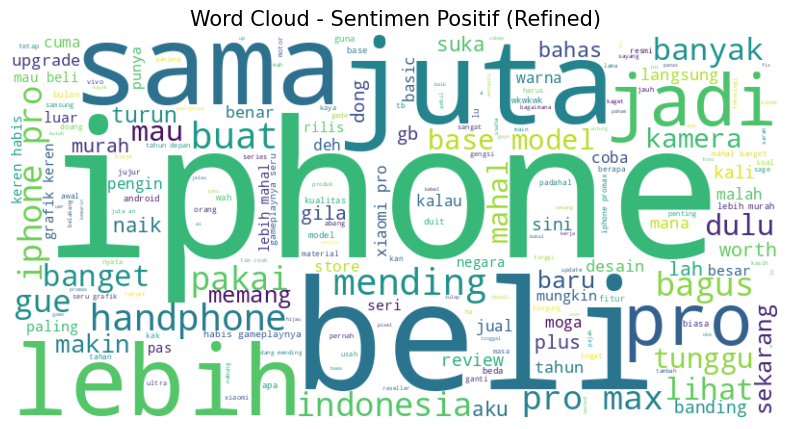

Generating Word Cloud: NEGATIF...


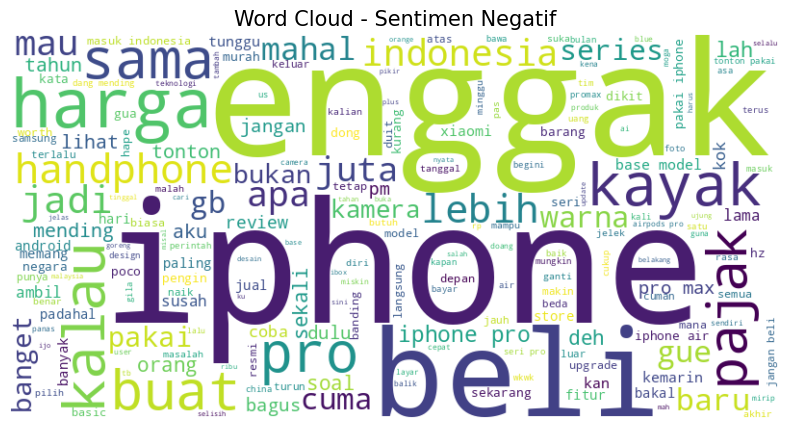

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Pastikan data frame visualisasi sudah siap (sesuai kode Anda)
df_viz = pd.DataFrame({'text': X_raw, 'label_otomatis': y_raw}).copy()

# ==========================================
# 1. DEFINISI STOPWORDS (FILTER KATA)
# ==========================================
# Ini daftar kata yang ingin Anda hilangkan dari gambar
# Masukkan "mahal", "enggak", dan kata umum lainnya di sini
stopwords_filter_positif = set([
    'enggak', 'gak', 'tidak', 'bukan', 'jangan', 'mahal'  # Kata Negasi
    'handphone', 'apple', 'ponsel', 'juta'# Kata Benda Umum (Biar fokus ke kata sifat)
    'nya', 'aja', 'sih', 'kok', 'tuh', 'yang', 'dan', 'di', 'ke', 'harga' # Kata Sambung
])

# Untuk negatif, kita mungkin tetap butuh kata 'mahal', jadi buat filter beda (opsional)
stopwords_filter_umum = set(['hp', 'apple', 'nya', 'aja', 'yang'])

# ==========================================
# 2. UPDATE FUNGSI WORDCLOUD
# ==========================================
def generate_wordcloud(text_data, title, extra_stopwords=None):
    # Gabungkan teks
    all_text = " ".join(text_data.astype(str))

    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap='viridis',
                          max_words=200,
                          # KUNCI UTAMA: Masukkan parameter stopwords di sini
                          stopwords=extra_stopwords
                          ).generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=15)
    plt.show()

# ==========================================
# 3. EKSEKUSI
# ==========================================

# --- Word Cloud Positif (DIBERSIHKAN AGRESIF) ---
print("Generating Word Cloud: POSITIF...")
text_positif = df_viz[df_viz['label_otomatis'] == 'Positif']['text']

if len(text_positif) > 0:
    # Perhatikan: Kita memasukkan 'stopwords_filter_positif' di sini
    generate_wordcloud(text_positif,
                       "Word Cloud - Sentimen Positif (Refined)",
                       extra_stopwords=stopwords_filter_positif)

# --- Word Cloud Negatif (NORMAL) ---
print("Generating Word Cloud: NEGATIF...")
text_negatif = df_viz[df_viz['label_otomatis'] == 'Negatif']['text']

if len(text_negatif) > 0:
    # Untuk negatif, kita pakai filter umum saja (kata "mahal" tetap akan muncul karena relevan)
    generate_wordcloud(text_negatif,
                       "Word Cloud - Sentimen Negatif",
                       extra_stopwords=stopwords_filter_umum)

/tmp/ipython-input-2185256229.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Jumlah', y='Kata', data=df_top, palette='viridis')


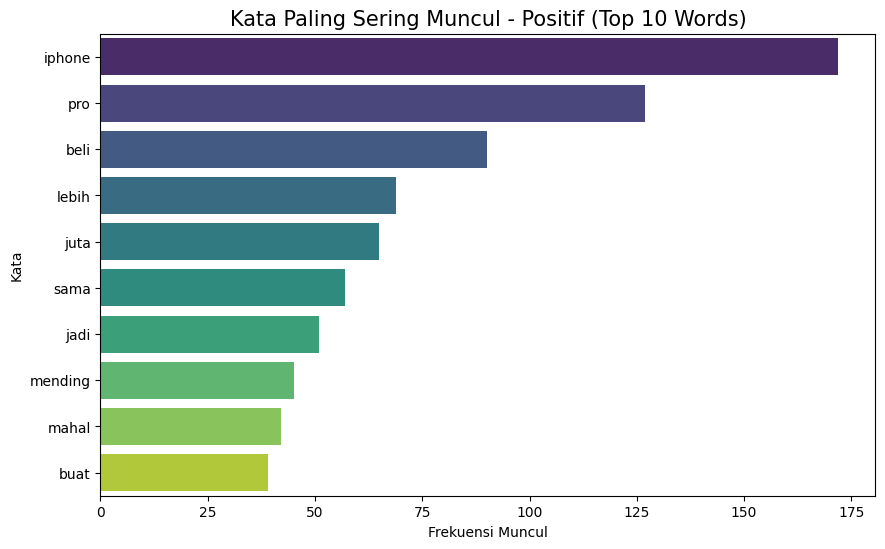

--- Data Angka Kata Paling Sering Muncul - Positif ---
      Kata  Jumlah
0   iphone     172
1      pro     127
2     beli      90
3    lebih      69
4     juta      65
5     sama      57
6     jadi      51
7  mending      45
8    mahal      42
9     buat      39




/tmp/ipython-input-2185256229.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Jumlah', y='Kata', data=df_top, palette='viridis')


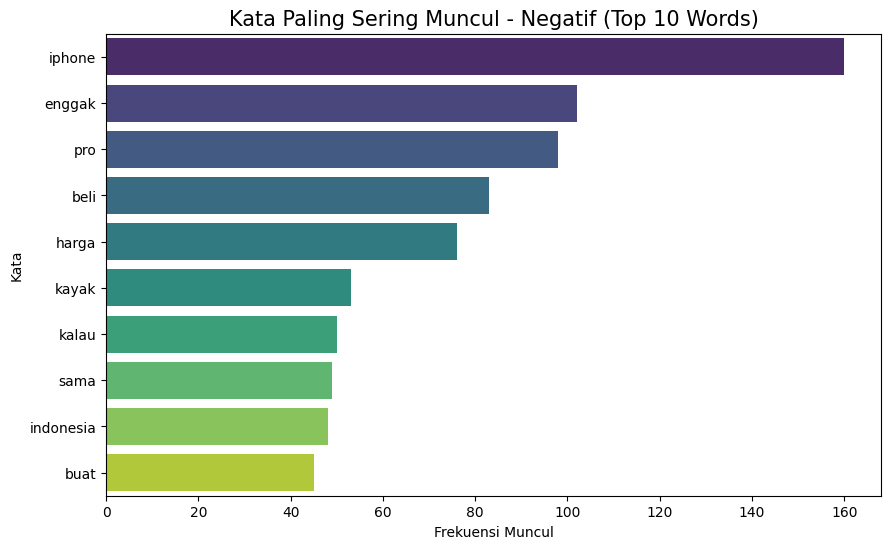

--- Data Angka Kata Paling Sering Muncul - Negatif ---
        Kata  Jumlah
0     iphone     160
1     enggak     102
2        pro      98
3       beli      83
4      harga      76
5      kayak      53
6      kalau      50
7       sama      49
8  indonesia      48
9       buat      45




In [ ]:
from collections import Counter
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# FUNGSI MENGHITUNG & PLOTTING
# ==========================================
def plot_top_words(df, label_target, title, stopwords_set=None, n_top=15):
    # 1. Ambil data teks berdasarkan label (Positif/Negatif)
    texts = df[df['label_otomatis'] == label_target]['text']

    # 2. Tokenisasi & Filter Stopwords
    all_words = []
    for sentence in texts:
        # Pisahkan kalimat jadi kata-kata
        words = str(sentence).split()
        for word in words:
            # Masukkan kata jika TIDAK ada di daftar stopwords
            if stopwords_set and word not in stopwords_set:
                all_words.append(word)
            elif not stopwords_set:
                all_words.append(word)

    # 3. Hitung Frekuensi
    word_counts = Counter(all_words)

    # 4. Ambil N kata terbanyak
    top_words = word_counts.most_common(n_top)

    # 5. Buat DataFrame untuk Plotting
    df_top = pd.DataFrame(top_words, columns=['Kata', 'Jumlah'])

    # 6. Plotting Bar Chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Jumlah', y='Kata', data=df_top, palette='viridis')
    plt.title(f'{title} (Top {n_top} Words)', fontsize=15)
    plt.xlabel('Frekuensi Muncul')
    plt.ylabel('Kata')
    plt.show()

    # Print angkanya juga biar jelas
    print(f"--- Data Angka {title} ---")
    print(df_top)
    print("\n")

# ==========================================
# EKSEKUSI (Gunakan Stopwords yang sama dengan Word Cloud tadi)
# ==========================================

# Pastikan set stopwords dari langkah sebelumnya sudah didefinisikan
# Jika belum, uncomment baris di bawah ini:
# stopwords_filter_positif = set(['enggak', 'mahal', 'iphone', 'hp', 'nya', 'aja', 'sih', 'kok'])
# stopwords_filter_umum = set(['iphone', 'hp', 'nya', 'aja'])

# 1. Top Words Positif
plot_top_words(df_viz, 'Positif', 'Kata Paling Sering Muncul - Positif',
               stopwords_set=stopwords_filter_positif, n_top=10)

# 2. Top Words Negatif
plot_top_words(df_viz, 'Negatif', 'Kata Paling Sering Muncul - Negatif',
               stopwords_set=stopwords_filter_umum, n_top=10)

In [ ]:
# Pilih satu model untuk dicek (Misal Naive Bayes)
model_cek = nb_model
y_pred_cek = model_cek.predict(X_test)

# Kembalikan angka ke label teks
y_test_label = le.inverse_transform(y_test)
y_pred_label = le.inverse_transform(y_pred_cek)

# Buat DataFrame hasil prediksi
df_error = pd.DataFrame({
    'Text_Asli': X_test_raw if 'X_test_raw' in locals() else "Teks ter-enkripsi di TF-IDF",
    # Catatan: Karena X sudah jadi angka TF-IDF, kita susah baca teks aslinya di sini
    # kecuali kita simpan indexnya sebelum split.
    # Tapi kita bisa bandingkan labelnya saja:
    'Label_Asli': y_test_label,
    'Prediksi_Model': y_pred_label
})

# Filter yang SALAH saja
df_salah = df_error[df_error['Label_Asli'] != df_error['Prediksi_Model']]

print(f"Total Kesalahan Prediksi: {len(df_salah)} dari {len(y_test)} data uji.")
print("\n--- Contoh 5 Data yang Salah Diprediksi ---")
print(df_salah.head())

# TIPS:
# Jika output kolom 'Text_Asli' tidak muncul teksnya,
# itu wajar karena X_train/test sudah berupa angka TF-IDF.
# Analisisnya: "Model sering salah memprediksi Netral menjadi Negatif" (lihat pola tabel di atas).

Total Kesalahan Prediksi: 76 dari 214 data uji.

--- Contoh 5 Data yang Salah Diprediksi ---
                      Text_Asli Label_Asli Prediksi_Model
5   Teks ter-enkripsi di TF-IDF     Netral        Positif
8   Teks ter-enkripsi di TF-IDF     Netral        Positif
13  Teks ter-enkripsi di TF-IDF     Netral        Positif
14  Teks ter-enkripsi di TF-IDF    Negatif        Positif
16  Teks ter-enkripsi di TF-IDF     Netral        Positif
